Q2: Battery-Aware Robot Navigation

Defining Environment

In [2]:
GRID_SIZE = 10
B = 6
GAMMA = 0.9
GOAL = (9, 9)
CHARGING_STATIONS = {(1, 3), (5, 8), (2,7)}
#CHARGING_STATIONS = {(1, 3), (7, 5), (3,4)}
# CHARGING_STATIONS = {(8,0)}


FAILURE_STATE = "FAILURE"
states_battery = []

for x in range(GRID_SIZE):
    for y in range(GRID_SIZE):
        for b in range(B+1):
            states_battery.append((x, y, b))

states_battery.append(FAILURE_STATE)

terminal_states_battery = {FAILURE_STATE}

# Goal states are terminal
for b in range(B+1):
    terminal_states_battery.add((GOAL[0], GOAL[1], b))


def get_available_actions(state):               #I added this function as i didn't want to allow recharge action at non charging stations

    if state in terminal_states_battery:
        return []

    x, y, b = state

    actions = ["Up", "Down", "Left", "Right"]

    if (x, y) in CHARGING_STATIONS:
        actions.append("Recharge")

    return actions




def get_transitions_battery(state, action):

    if state in terminal_states_battery:
        return []

    x, y, b = state

    if action == "Recharge":

        if (x, y) in CHARGING_STATIONS:
            return [(1.0, (x, y, B), -2)]
        else:
            return [(1.0, (x, y, b), -2)]  # self-loop


    if b == 0:
        return [(1.0, FAILURE_STATE, -100)]

    if action == "Up":
        nx, ny = x, y+1
    elif action == "Down":
        nx, ny = x, y-1
    elif action == "Left":
        nx, ny = x-1, y
    elif action == "Right":
        nx, ny = x+1, y

    # valid or not
    if nx < 0 or nx >= GRID_SIZE or ny < 0 or ny >= GRID_SIZE:
        nx, ny = x, y   # stay in place

    new_b = b - 1


    if new_b == 0 and (nx, ny) not in CHARGING_STATIONS and (nx, ny) != GOAL:       # Battery depletion
        return [(1.0, FAILURE_STATE, -100)]


    if (nx, ny) == GOAL:                                                            # Goal reached
        return [(1.0, (nx, ny, new_b), 100)]

    return [(1.0, (nx, ny, new_b), -1)]



Value Iteration

In [3]:
def run_value_iteration_battery(states, terminal_states, tol=1e-4, max_iters=1000):

    V = {s: 0.0 for s in states}
    iterations = 0

    for k in range(max_iters):
        delta = 0
        V_new = V.copy()

        for s in states:
            if s in terminal_states:
                continue

            best_val = -float("inf")

            for a in get_available_actions(s):
                val = 0
                transitions = get_transitions_battery(s, a)

                for p, s_next, r in transitions:
                    val += p * (r + GAMMA * V[s_next])

                best_val = max(best_val, val)

            delta = max(delta, abs(best_val - V[s]))
            V_new[s] = best_val

        V = V_new
        iterations += 1

        if delta < tol:
            break

    # Extracting the optimal policy
    policy = {}

    for s in states:
        if s in terminal_states:
            continue

        best_action = None
        best_val = -float("inf")

        for a in get_available_actions(s):
            val = 0
            transitions = get_transitions_battery(s, a)

            for p, s_next, r in transitions:
                val += p * (r + GAMMA * V[s_next])

            if val > best_val:
                best_val = val
                best_action = a

        policy[s] = best_action

    return V, policy, iterations


V_battery, policy_battery, iters_battery = run_value_iteration_battery(
    states_battery,
    terminal_states_battery
)

print("Value Iteration converged in:", iters_battery, "iterations")


Value Iteration converged in: 24 iterations


Simulating for a starting path

Path length: 22
Battery levels along path: [6, 5, 4, 3, 2, 6, 5, 4, 3, 2, 1, 6, 5, 4, 3, 2, 6, 5, 4, 3, 2, 1]


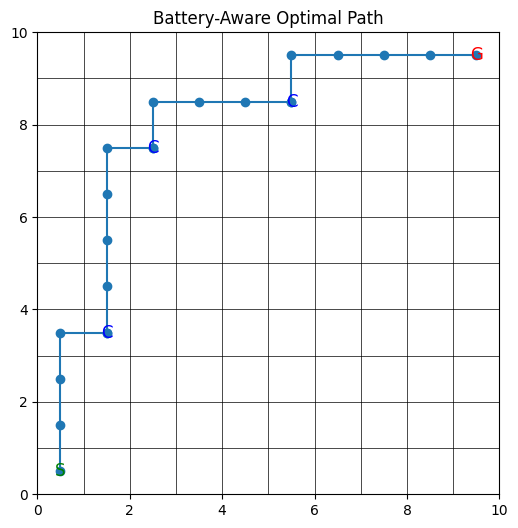

In [4]:
start_state = (0, 0, B)

def simulate_path(policy, start_state, max_steps=100):

    state = start_state
    path = []
    battery_levels = []

    for _ in range(max_steps):

        if state == FAILURE_STATE:
            print("Reached FAILURE state")
            break

        x, y, b = state
        path.append((x, y))
        battery_levels.append(b)

        if state in terminal_states_battery:
            break

        action = policy[state]
        transitions = get_transitions_battery(state, action)

        if not transitions:
            break

        _, next_state, _ = transitions[0]

        state = next_state

    return path, battery_levels

start_state = (0, 0, B)

path, battery_levels = simulate_path(policy_battery, start_state)


import matplotlib.pyplot as plt

def plot_path(path):

    plt.figure(figsize=(6,6))

    for i in range(GRID_SIZE+1):
        plt.plot([0, GRID_SIZE], [i, i], color='black', linewidth=0.5)
        plt.plot([i, i], [0, GRID_SIZE], color='black', linewidth=0.5)

    xs = [p[0] + 0.5 for p in path]
    ys = [p[1] + 0.5 for p in path]

    plt.plot(xs, ys, marker='o')

    plt.text(path[0][0] + 0.5, path[0][1] + 0.5, "S",
             ha='center', va='center', fontsize=12, color='green')


    gx, gy = GOAL
    plt.text(gx + 0.5, gy + 0.5, "G",
             ha='center', va='center', fontsize=12, color='red')

    for (cx, cy) in CHARGING_STATIONS:
        plt.text(cx + 0.5, cy + 0.5, "C",
                 ha='center', va='center', fontsize=12, color='blue')

    plt.xlim(0, GRID_SIZE)
    plt.ylim(0, GRID_SIZE)
    plt.gca().set_aspect('equal')
    plt.title("Battery-Aware Optimal Path")
    plt.show()



print("Path length:", len(path))
print("Battery levels along path:", battery_levels)

plot_path(path)


Policy Iteration

In [5]:
import random
def run_policy_iteration_battery(states, terminal_states, tol=1e-4, max_iters=1000):

    policy = {}

    for s in states:
        if s not in terminal_states:
            actions = get_available_actions(s)
            if actions:
                policy[s] = random.choice(actions)

    V = {s: 0.0 for s in states}

    iterations = 0

    for k in range(max_iters):

        # Policy Evaluation
        while True:

            delta = 0
            V_new = V.copy()

            for s in states:

                if s in terminal_states:
                    continue

                a = policy[s]
                val = 0

                transitions = get_transitions_battery(s, a)

                for p, s_next, r in transitions:
                    val += p * (r + GAMMA * V[s_next])

                delta = max(delta, abs(val - V[s]))
                V_new[s] = val

            V = V_new

            if delta < tol:
                break

        # Policy Improvement
        policy_stable = True

        for s in states:

            if s in terminal_states:
                continue

            old_action = policy[s]

            best_action = None
            best_val = -float("inf")

            for a in get_available_actions(s):

                val = 0
                transitions = get_transitions_battery(s, a)

                for p, s_next, r in transitions:
                    val += p * (r + GAMMA * V[s_next])

                if val > best_val:
                    best_val = val
                    best_action = a

            policy[s] = best_action

            if best_action != old_action:
                policy_stable = False

        iterations += 1

        if policy_stable:
            break

    return V, policy, iterations

V_pi_battery, policy_pi_battery, pi_iters = run_policy_iteration_battery(
    states_battery,
    terminal_states_battery
)

print("Battery-aware Policy Iteration converged in:", pi_iters, "iterations")


Battery-aware Policy Iteration converged in: 13 iterations


PI Path length: 22
PI Battery levels: [6, 5, 4, 3, 2, 6, 5, 4, 3, 2, 1, 6, 5, 4, 3, 2, 6, 5, 4, 3, 2, 1]


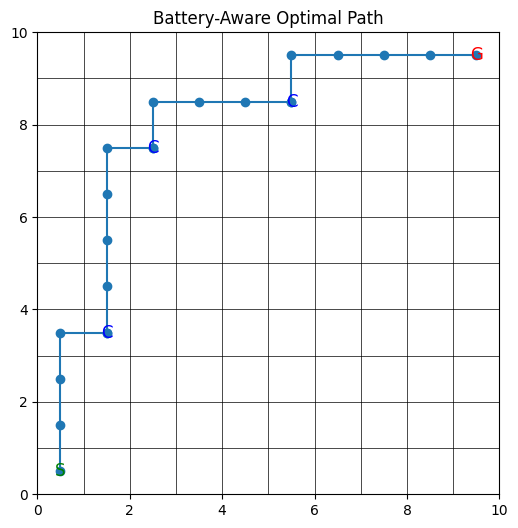

In [6]:
start_state = (0, 0, B)

path_pi, battery_levels_pi = simulate_path(policy_pi_battery, start_state)

print("PI Path length:", len(path_pi))
print("PI Battery levels:", battery_levels_pi)

plot_path(path_pi)


Plotting value iteration vs policy iteration till convergence 

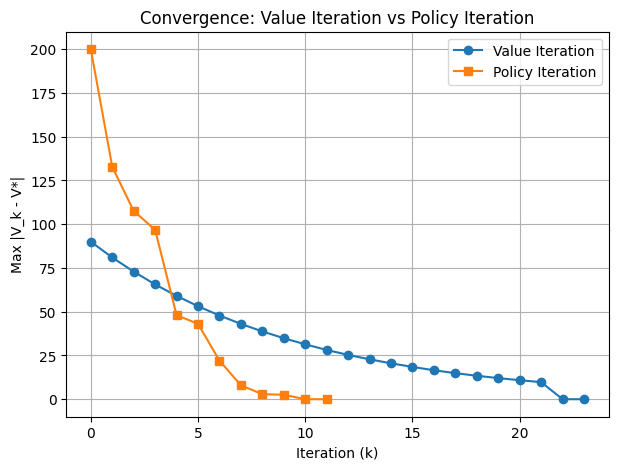

In [7]:
V_star, _, _ = run_value_iteration_battery(
    states_battery,
    terminal_states_battery
)
def value_iteration_convergence(states, terminal_states, tol=1e-4, max_iters=1000):

    V = {s: 0.0 for s in states}
    errors = []

    for k in range(max_iters):

        delta = 0
        V_new = V.copy()

        for s in states:
            if s in terminal_states:
                continue

            best_val = -float("inf")

            for a in get_available_actions(s):
                val = 0
                transitions = get_transitions_battery(s, a)

                for p, s_next, r in transitions:
                    val += p * (r + GAMMA * V[s_next])

                best_val = max(best_val, val)

            delta = max(delta, abs(best_val - V[s]))
            V_new[s] = best_val

        V = V_new

        # Compute error w.r.t V*
        max_error = 0
        for s in states:
            max_error = max(max_error, abs(V[s] - V_star[s]))

        errors.append(max_error)

        if delta < tol:
            break

    return errors
def policy_iteration_convergence(states, terminal_states, tol=1e-4, max_iters=1000):

    import random

    policy = {}
    for s in states:
        if s not in terminal_states:
            actions = get_available_actions(s)
            if actions:
                policy[s] = random.choice(actions)

    V = {s: 0.0 for s in states}
    errors = []

    for k in range(max_iters):

        # Policy Evaluation
        while True:
            delta = 0
            V_new = V.copy()

            for s in states:
                if s in terminal_states:
                    continue

                a = policy[s]
                val = 0
                transitions = get_transitions_battery(s, a)

                for p, s_next, r in transitions:
                    val += p * (r + GAMMA * V[s_next])

                delta = max(delta, abs(val - V[s]))
                V_new[s] = val

            V = V_new

            if delta < tol:
                break

        # Compute error w.r.t V*
        max_error = 0
        for s in states:
            max_error = max(max_error, abs(V[s] - V_star[s]))

        errors.append(max_error)

        # Policy Improvement
        policy_stable = True

        for s in states:
            if s in terminal_states:
                continue

            old_action = policy[s]

            best_action = None
            best_val = -float("inf")

            for a in get_available_actions(s):

                val = 0
                transitions = get_transitions_battery(s, a)

                for p, s_next, r in transitions:
                    val += p * (r + GAMMA * V[s_next])

                if val > best_val:
                    best_val = val
                    best_action = a

            policy[s] = best_action

            if best_action != old_action:
                policy_stable = False

        if policy_stable:
            break

    return errors


vi_errors = value_iteration_convergence(
    states_battery,
    terminal_states_battery
)

pi_errors = policy_iteration_convergence(
    states_battery,
    terminal_states_battery
)

import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

plt.plot(vi_errors, marker='o', label="Value Iteration")
plt.plot(pi_errors, marker='s', label="Policy Iteration")

plt.xlabel("Iteration (k)")
plt.ylabel("Max |V_k - V*|")
plt.title("Convergence: Value Iteration vs Policy Iteration")
plt.legend()
plt.grid(True)

plt.show()


## SARSA


In [8]:
import random
import numpy as np
import time
import tracemalloc


def epsilon_greedy_battery(Q, state, epsilon):
    actions = get_available_actions(state)

    if random.random() < epsilon:
        return random.choice(actions)

    return max(actions, key=lambda a: Q[(state, a)])



def run_sarsa_battery(states, terminal_states, GAMMA, get_available_actions, get_transitions,
                      episodes=5000, alpha=0.1, epsilon=0.1, max_steps=200):

    Q = {}
    for s in states:
        if s not in terminal_states:
            for a in get_available_actions(s):
                Q[(s, a)] = 0.0

    returns = []
    lengths = []

    start_time = time.time()
    tracemalloc.start()

    non_terminal_states = [s for s in states if s not in terminal_states]

    for ep in range(episodes):
        episode_return = 0
        episode_length = 0

        state = random.choice(non_terminal_states)
        action = epsilon_greedy_battery(Q, state, epsilon)
        steps = 0

        while state not in terminal_states and steps < max_steps:
            transitions = get_transitions(state, action)
            probs = [t[0] for t in transitions]
            choice = np.random.choice(len(transitions), p=probs)
            _, next_state, reward = transitions[choice]

            episode_return += reward
            episode_length += 1
            steps += 1

            if next_state in terminal_states:
                target = reward
                Q[(state, action)] += alpha * (target - Q[(state, action)])
                break

            next_action = epsilon_greedy_battery(Q, next_state, epsilon)
            target = reward + GAMMA * Q[(next_state, next_action)]
            Q[(state, action)] += alpha * (target - Q[(state, action)])

            state = next_state
            action = next_action

        returns.append(episode_return)
        lengths.append(episode_length)

    current, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    runtime = time.time() - start_time

    policy = {}
    for s in states:
        if s in terminal_states:
            continue
        policy[s] = max(get_available_actions(s), key=lambda a: Q[(s, a)])

    return Q, policy, runtime, peak, returns, lengths


## N STEP SARSA


In [9]:
def run_n_step_sarsa_battery(states, terminal_states, GAMMA, get_available_actions, get_transitions,
                             n=3, episodes=5000, alpha=0.1, epsilon=0.1, max_steps=200):

    Q = {}
    for s in states:
        if s not in terminal_states:
            for a in get_available_actions(s):
                Q[(s, a)] = 0.0

    returns = []
    lengths = []

    start_time = time.time()
    tracemalloc.start()

    non_terminal_states = [s for s in states if s not in terminal_states]

    for ep in range(episodes):
        episode_return = 0
        episode_length = 0

        state = random.choice(non_terminal_states)
        action = epsilon_greedy_battery(Q, state, epsilon)

        states_buffer = [state]
        actions_buffer = [action]
        rewards_buffer = [0.0]

        T = float('inf')
        t = 0
        steps = 0

        while True:
            if t < T:
                transitions = get_transitions(state, action)
                probs = [tr[0] for tr in transitions]
                choice = np.random.choice(len(transitions), p=probs)
                _, next_state, reward = transitions[choice]

                episode_return += reward
                episode_length += 1
                steps += 1

                states_buffer.append(next_state)
                rewards_buffer.append(reward)

                if next_state in terminal_states or steps >= max_steps:
                    T = t + 1
                else:
                    next_action = epsilon_greedy_battery(Q, next_state, epsilon)
                    actions_buffer.append(next_action)
                    state = next_state
                    action = next_action

            tau = t - n + 1

            if tau >= 0:
                G = 0.0

                for i in range(tau + 1, min(tau + n, T) + 1):
                    G += (GAMMA ** (i - tau - 1)) * rewards_buffer[i]

                if tau + n < T:
                    G += (GAMMA ** n) * Q[(states_buffer[tau + n], actions_buffer[tau + n])]

                if states_buffer[tau] not in terminal_states:
                    key = (states_buffer[tau], actions_buffer[tau])
                    Q[key] += alpha * (G - Q[key])

            if tau == T - 1:
                break

            t += 1

        returns.append(episode_return)
        lengths.append(episode_length)

    current, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    runtime = time.time() - start_time

    policy = {}
    for s in states:
        if s in terminal_states:
            continue
        policy[s] = max(get_available_actions(s), key=lambda a: Q[(s, a)])

    return Q, policy, runtime, peak, returns, lengths


In [10]:
print("Running SARSA...")
Q_sarsa_b, policy_sarsa_b, time_sarsa_b, mem_sarsa_b, returns_sarsa_b, lengths_sarsa_b = run_sarsa_battery(
    states_battery,
    terminal_states_battery,
    GAMMA,
    get_available_actions,
    get_transitions_battery
)

print("Running n-step SARSA for different n...")
results_b = {}

for n in [1, 3, 5, 10]:
    Q_n, policy_n, time_n, mem_n, returns_n, lengths_n = run_n_step_sarsa_battery(
        states_battery,
        terminal_states_battery,
        GAMMA,
        get_available_actions,
        get_transitions_battery,
        n=n
    )

    results_b[n] = {
        "returns": returns_n,
        "lengths": lengths_n,
        "time": time_n,
        "mem": mem_n,
    }

    print(f"n={n} -> Time: {time_n:.4f}s, Memory: {mem_n/1024:.2f} KB")


Running SARSA...
Running n-step SARSA for different n...
n=1 -> Time: 1.3045s, Memory: 271.32 KB
n=3 -> Time: 1.5230s, Memory: 267.39 KB
n=5 -> Time: 2.4840s, Memory: 261.30 KB
n=10 -> Time: 1.2845s, Memory: 260.01 KB


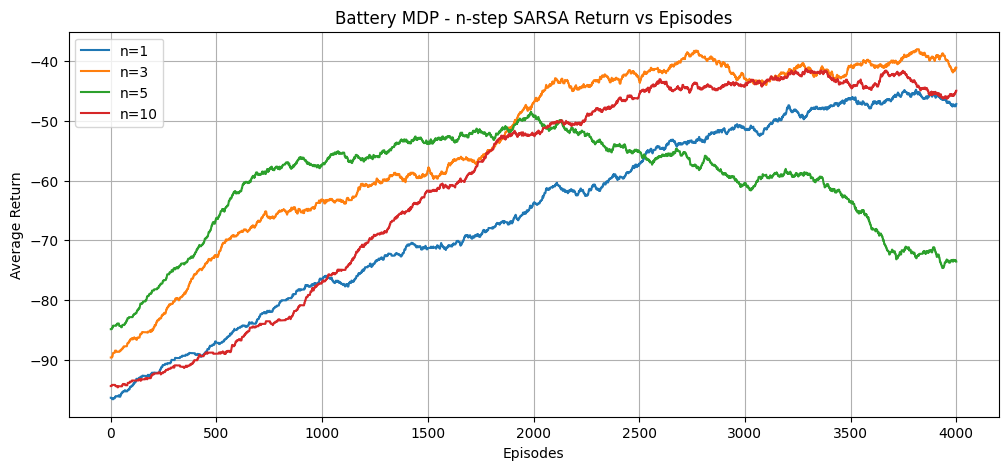

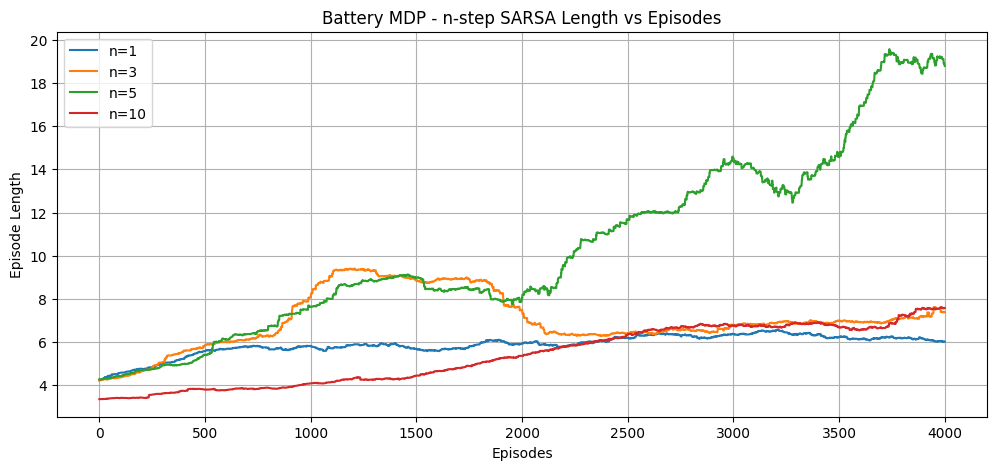

In [ ]:
import matplotlib.pyplot as plt


def moving_avg(x, window=50):
    if len(x) < window:
        return x

    return np.convolve(x, np.ones(window) / window, mode='valid')


window = 50

plt.figure(figsize=(12, 5))
for n in sorted(results_b.keys()):
    plt.plot(moving_avg(results_b[n]["returns"], window), label=f"n={n}")

plt.xlabel("Episodes")
plt.ylabel("Average Return")
plt.title("Battery MDP - n-step SARSA Return vs Episodes")
plt.legend()
plt.grid()

plt.figure(figsize=(12, 5))
for n in sorted(results_b.keys()):
    plt.plot(moving_avg(results_b[n]["lengths"], window), label=f"n={n}")

plt.xlabel("Episodes")
plt.ylabel("Episode Length")
plt.title("Battery MDP - n-step SARSA Length vs Episodes")
plt.legend()
plt.grid()

plt.show()


## Q learning


In [12]:
def Q_to_V_battery(Q, states, terminal_states, get_available_actions):
    V = {}

    for s in states:
        if s in terminal_states:
            V[s] = 0.0
        else:
            V[s] = max(Q[(s, a)] for a in get_available_actions(s))

    return V



def run_q_learning_battery(states, terminal_states, GAMMA, get_available_actions, get_transitions,
                           V_optimal,
                           alpha_start=0.1,
                           epsilon_start=0.1,
                           epsilon_min=0.01,
                           episodes=5000,
                           max_steps=200):

    Q = {}
    for s in states:
        if s not in terminal_states:
            for a in get_available_actions(s):
                Q[(s, a)] = 0.0

    returns = []
    lengths = []
    value_errors = []

    start_time = time.time()
    tracemalloc.start()

    non_terminal_states = [s for s in states if s not in terminal_states]

    alpha = alpha_start
    epsilon = epsilon_start

    for ep in range(episodes):
        state = random.choice(non_terminal_states)

        episode_return = 0
        episode_length = 0
        steps = 0

        while state not in terminal_states and steps < max_steps:
            actions = get_available_actions(state)

            if random.random() < epsilon:
                action = random.choice(actions)
            else:
                action = max(actions, key=lambda a: Q[(state, a)])

            transitions = get_transitions(state, action)
            probs = [t[0] for t in transitions]
            choice = np.random.choice(len(transitions), p=probs)
            _, next_state, reward = transitions[choice]

            episode_return += reward
            episode_length += 1
            steps += 1

            if next_state in terminal_states:
                target = reward
            else:
                next_actions = get_available_actions(next_state)
                best_next = max(Q[(next_state, a)] for a in next_actions)
                target = reward + GAMMA * best_next

            Q[(state, action)] += alpha * (target - Q[(state, action)])
            state = next_state

        returns.append(episode_return)
        lengths.append(episode_length)

        epsilon = max(epsilon_min, epsilon_start * (0.995 ** ep))
        alpha = alpha_start / (1 + 0.001 * ep)

        V_current = Q_to_V_battery(Q, states, terminal_states, get_available_actions)
        error = np.mean([abs(V_current[s] - V_optimal[s]) for s in V_optimal])
        value_errors.append(error)

    current, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    runtime = time.time() - start_time

    policy = {}
    for s in states:
        if s in terminal_states:
            continue
        actions = get_available_actions(s)
        policy[s] = max(actions, key=lambda a: Q[(s, a)])

    return Q, policy, runtime, peak, returns, lengths, value_errors


Q_q_b, policy_q_b, time_q_b, mem_q_b, returns_q_b, lengths_q_b, value_errors_q_b = run_q_learning_battery(
    states_battery,
    terminal_states_battery,
    GAMMA,
    get_available_actions,
    get_transitions_battery,
    V_battery
)


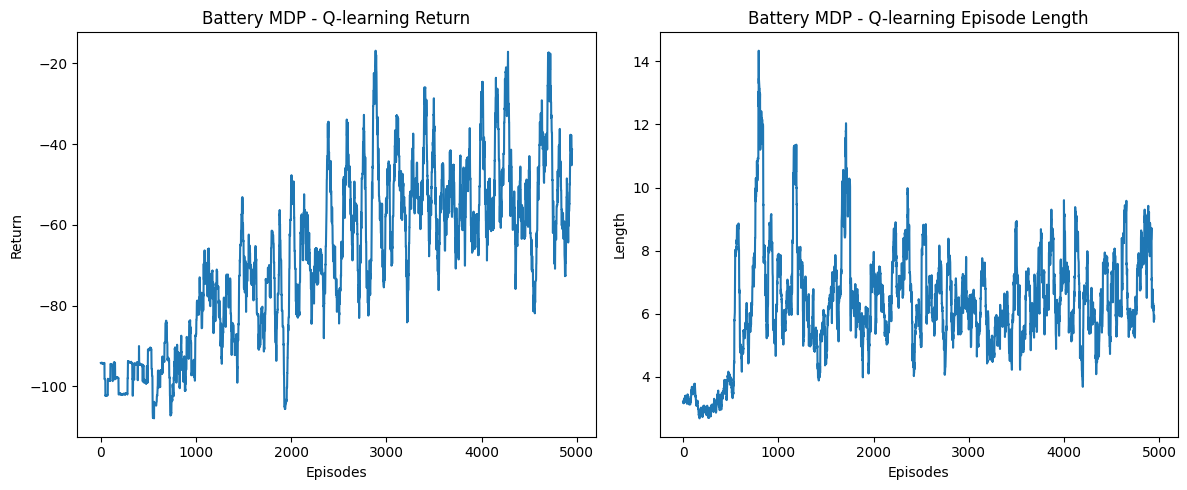

In [13]:
window = 50

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(moving_avg(returns_q_b, window))
plt.title("Battery MDP - Q-learning Return")
plt.xlabel("Episodes")
plt.ylabel("Return")

plt.subplot(1, 2, 2)
plt.plot(moving_avg(lengths_q_b, window))
plt.title("Battery MDP - Q-learning Episode Length")
plt.xlabel("Episodes")
plt.ylabel("Length")

plt.tight_layout()
plt.show()


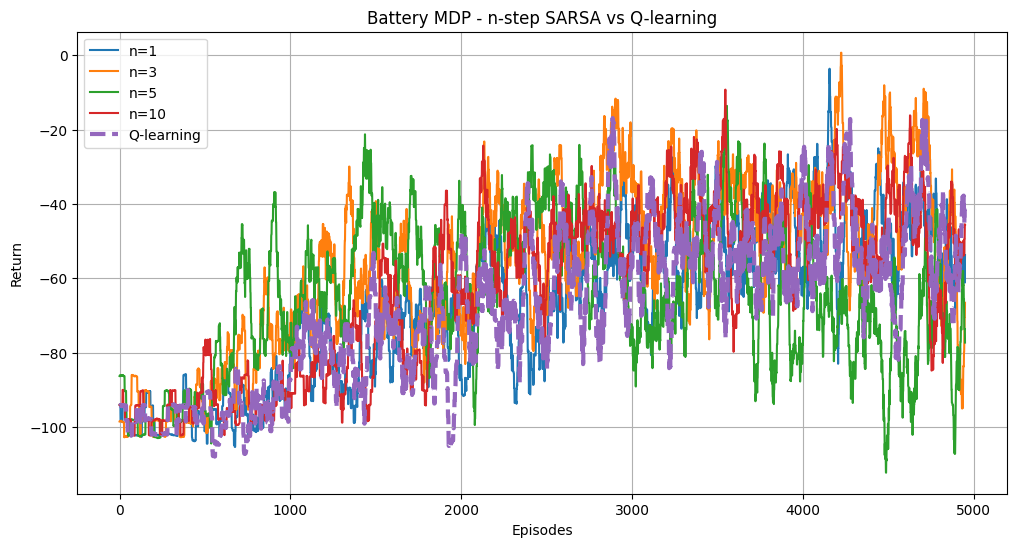

In [14]:
plt.figure(figsize=(12, 6))

for n in sorted(results_b.keys()):
    plt.plot(moving_avg(results_b[n]["returns"], window), label=f"n={n}")

plt.plot(moving_avg(returns_q_b, window), label="Q-learning", linewidth=3, linestyle='--')

plt.xlabel("Episodes")
plt.ylabel("Return")
plt.title("Battery MDP - n-step SARSA vs Q-learning")
plt.legend()
plt.grid()
plt.show()


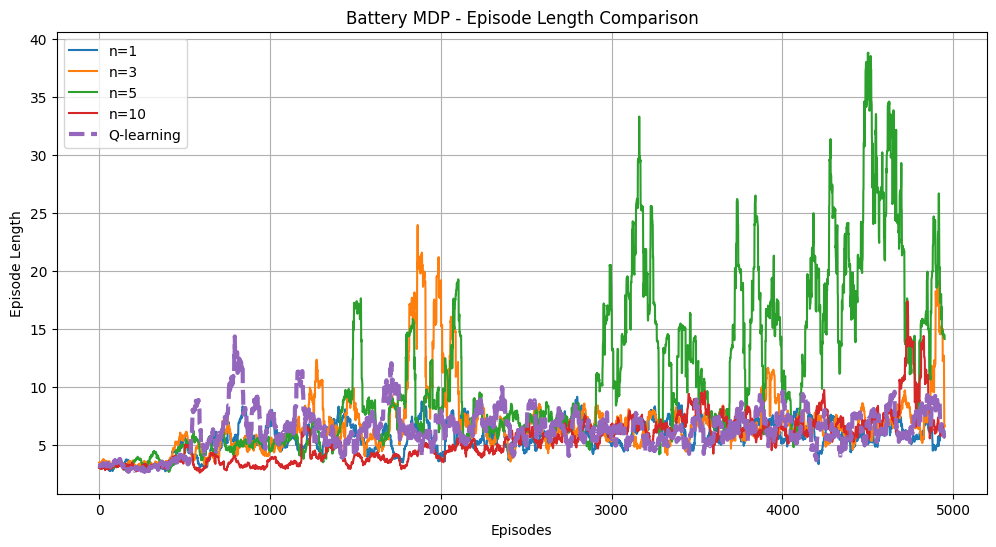

In [15]:
plt.figure(figsize=(12, 6))

for n in sorted(results_b.keys()):
    plt.plot(moving_avg(results_b[n]["lengths"], window), label=f"n={n}")

plt.plot(moving_avg(lengths_q_b, window), label="Q-learning", linewidth=3, linestyle='--')

plt.xlabel("Episodes")
plt.ylabel("Episode Length")
plt.title("Battery MDP - Episode Length Comparison")
plt.legend()
plt.grid()
plt.show()


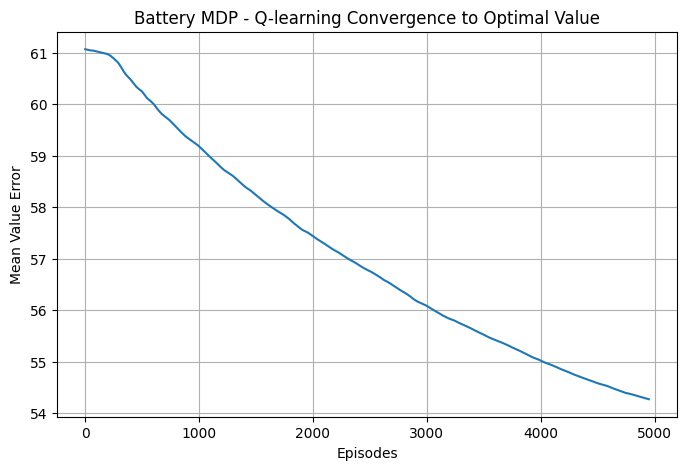

In [16]:
plt.figure(figsize=(8, 5))
plt.plot(moving_avg(value_errors_q_b, window))
plt.xlabel("Episodes")
plt.ylabel("Mean Value Error")
plt.title("Battery MDP - Q-learning Convergence to Optimal Value")
plt.grid()
plt.show()


In [17]:
print("Final Performance Comparison")
print(f"{'Method':<20} {'Time (s)':<10} {'Memory (KB)':<12}")
print("-" * 45)
print(f"{'SARSA':<20} {time_sarsa_b:<10.4f} {mem_sarsa_b / 1024:<12.2f}")

for n in sorted(results_b.keys()):
    print(f"{f'n-step SARSA (n={n})':<20} {results_b[n]['time']:<10.4f} {results_b[n]['mem'] / 1024:<12.2f}")

print(f"{'Q-learning':<20} {time_q_b:<10.4f} {mem_q_b / 1024:<12.2f}")


Final Performance Comparison
Method               Time (s)   Memory (KB) 
---------------------------------------------
SARSA                1.4005     797.96      
n-step SARSA (n=1)   1.3045     271.32      
n-step SARSA (n=3)   1.5230     267.39      
n-step SARSA (n=5)   2.4840     261.30      
n-step SARSA (n=10)  1.2845     260.01      
Q-learning           13.0794    517.41      
